# Travaux dirigés 4 - MAP201, thème équation différentielles

Le TP est à faire en python, où la réponse à chaque question est dans une cellule séparée. On veillera à écrire un code suffisamment clair pour être éventuellement réutilisé d'un exercice à l'autre. 

In [74]:
!jupyter nbconvert --to html TP_MAP201_2025_EDO_4.ipynb

[NbConvertApp] Converting notebook TP_MAP201_2025_EDO_4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 660882 bytes to TP_MAP201_2025_EDO_4.html


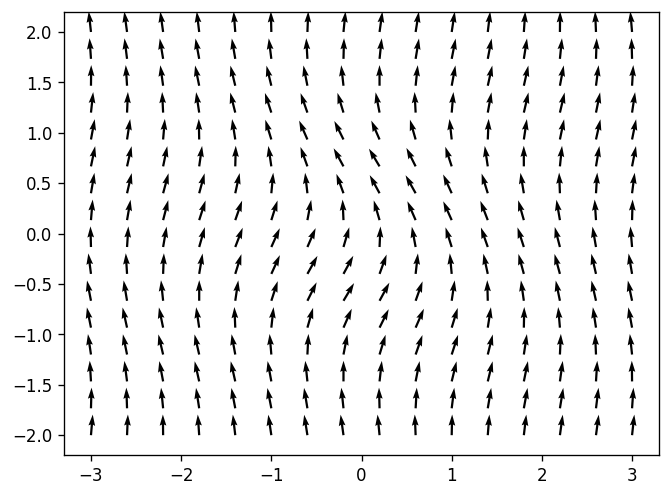

In [3]:
import numpy as np #importe les outils de gestion des tableaux
import matplotlib.pyplot as plt #importe les outils d'affichages matplotlib
plt.rcParams['figure.dpi'] = 120 #reglage facultatif de résolution des figures
plt.rcParams['savefig.dpi'] = 240 #reglage facultatif de résolution des figures enregistrées


#On introduit une fonction qui affiche, dans une zone [xmin,xmax]*[ymin,ymax], un champs de vecteur donné par une fonction (f(x,y),g(x,y))

def Affichage_Champs(f,g, xmin,xmax,ymin,ymax,p):
    #f,g: fonctions qui definissent le champs de vecteurs
    #xmin,xmax: intervalle d'abscisses affichees
    #ymin,ymax: intervalle d'ordonnees affichees
    #p: nombre de pas de discretisation
    x,y=np.meshgrid(np.linspace(xmin,xmax,p+1),np.linspace(ymin,ymax,p+1))
    u=f(x,y)
    v=g(x,y)
    u=u*(ymax-ymin)/(xmax-xmin)#Changement d'echelle.
    u,v=u/np.sqrt(0.01+u**2+v**2),v/np.sqrt(0.01+u**2+v**2)#Normalisation du champs de vecteur: cela permet de rendre plus visible la direction.
    plt.quiver(x,y,u,v)#affiche le champs de vecteur: cette fonction trace le vecteur (u[i,j],v[i,j]) base en (x[i,j],y[i,j]), pour i,j qui parcourent [0,N]x[0,N]

def g_exemple(x,y):
    return np.sqrt(1+x**2+y**4)#expression de h(x,y)

def f_exemple(x,y):
    return -np.sin(2*y+x)#expression de f(x,y)

Affichage_Champs(f=f_exemple,g=g_exemple,xmin=-3,xmax=3,ymin=-2,ymax=2,p=15)

# Exercice 1

On s'interesse ici aux équations de la forme $\ddot{x}(t)+\phi(x(t))=0$. On rappelle qu'en posant $y(t)=x'(t)$, celle-ci est équivalente au système $\begin{cases}\dot{x}(t)=y(t)\\ \dot{y}(t)=-\phi(x(t))\end{cases}$. On dit que $x^e$ est un point d'équilibre de l'équation $\ddot{x}(t)+\phi(x(t))=0$, si $(x^e,0)$ est un point d'équilibre du système associé, c'est-à-dire si $\phi(x^e)=0$.

On admet le résultat suivant: si $\phi'(x^e)>0$, alors $(x^e,0)$ est stable. Si au contraire $\phi'(x^e)<0$, alors $(x^e,0)$ est instable.

## 1)
On considère l'équation du pendule $\ddot{x}(t)+\frac{g}{\ell}\sin(x(t))=0$. Quels sont les points d'équilibre stables ? Instables ?

Réponse:
- Le système associé:

$\begin{cases}\dot{x}(t)=y(t)\\ \dot{y}(t)=-g/l   sin(x(t))\end{cases}$.


$\phi(xe)=0$ donc xe=kpi
Dans l'intervalle [0, 2pi[, les points d'équilibres sont 0 et pi.

$\phi'(0)>0$ -> équilibre stable.

$\phi'(pi)<0$ -> équilibre instable.

On suppose maintenant que le point d'attache du pendule est soumis à un mouvement sinusoïde vertical rapide: au temps $t$, la coordonnée verticale de celui-ci est $\epsilon \cos(v t/\epsilon))$ où $v>0$ est une constante homogène à une vitesse, et $\epsilon>0$ est une longueur qui tend vers $0$. On trouvera un exemple d'un tel pendule à https://www.youtube.com/watch?v=GgYABmG_bto.

On peut montrer que quand $\epsilon\to 0$, l'équation vérifiée par l'angle $x(t)$ est

$$\ddot{x}(t)+\frac{1}{\ell}\left(g+\frac{v^2}{2\ell}\cos\left(x(t)\right)\right)\sin(x(t))=0$$

## 2)
Expliquer le phénomène de la vidéo.

Réponse: 
- Le système associé:

$\begin{cases}\dot{x}(t)=y(t)\\ \dot{y}(t)=-1/l(g+v^2/2l cos(x(t)))   sin(x(t))\end{cases}$

avec $\phi(x)= -1/l(g+v^2/2l cos(x))$   sin(x)

$\phi'(x)= -1/l v^2/2l -sin(x)sin(x) + 1/l(g+v^2/2l cos(x))cos(x)$

$\phi'(pi)= -1/l(g - v^2/2l)(-1)=-1/l(v^2/2l - g)$

pi est point d'équilibre <=> $\phi'(pi)>0$ <=> v^2/2l>g <=> v>(2gl)^1/2

# Exercice 2 - Un autre modèle d'épidémie


On considère une variante du modèle SIR où il n'y a pas de phase d'immunité: les personnes rétablies sont immédiatement susceptibles d'être infectées à nouveaux.

  $x(t)$ est le nombre d'individus sains susceptible d'être infectés à l'instant $t$, et $y(t)$ est le nombre d'individus infectés, on suppose que $x(t)$, $y(t)$ suivent l'équation

$$
\begin{cases}
\dot{x}(t)=-\frac{kx(t)y(t)}{x(t)+y(t)}+\ell y(t),\ x(0)=x_0\\
\dot{y}(t)=\frac{kx(t)y(t)}{x(t)+y(t)}-\ell y(t),\ y(0)=y_0
\end{cases}
$$
Avec $x_0>0$, $y_0>0$. $k,\ell$ sont des constantes strictement positives.
## 1)
Donner une interprétation de chaque terme du modèle, et des constantes $k,\ell$.


Réponse:
- k - le taux de transmission de l’infection
- l - le taux de guérison

## 2)
Montrer que la population totale $x(t)+y(t)$ est constante en $t$.

Réponse:
- x(t) + y(t) = z(t)
$$
\dot{z}(t)=-\frac{kx(t)y(t)}{x(t)+y(t)}+\ell y(t) + \frac{kx(t)y(t)}{x(t)+y(t)}-\ell y(t) = 0
$$
comme la derivee est egale a zero la fonction z(t) est constante en t.

## 3) 
En déduire que la fonction $t\mapsto y(t)$ vérifie une équation différentielle ordinaire de la forme
$$
\dot{y}(t)=F(y(t))
$$
où on identifiera une fonction $F:\mathbb{R}\to\mathbb{R}$, qui peux dépendre de $x_0,y_0,k,\ell$, mais pas de l'inconnue $x(t)$.


Réponse: 
$$
\dot{y}(t)=\frac{kx(t)y(t)}{x(t)+y(t)}-\ell y(t),\ y(0)=y_0
$$
- et on a que x(t) + y(t) = z(t) et z(t) est constante posons z(t) = N 
- on a:
$$
\dot{y}(t)=\frac{( k N - k y(t) )y(t)}{N}-\ell y(t)
$$
$$
\dot{y}(t)= y(t) (\frac{ k N - k y(t)}{N}-\ell)
$$
- N = x0 + y0
$$
\dot{y}(t)= y(t) (\frac{ k (x0 + y0) -  k y(t)}{x0 + y0}-\ell)
$$
- donc on a:
$$
\dot{y}(t)= k y(t) - (\frac{y(t) * y(t))}{N})-\ell y(t)
$$
$$
\dot{y}(t)= y(t) * ( ( k - l ) - (\frac{y(t)}{N}))
$$
- la fonction qui depend de y(t) et les constantes k,l,N

## 4)
Déterminer les points points d'équilibre du système $\dot{y}(t)=F(y(t))$.


Réponse:
- F(0) = F(c) = 0

## 5)
On suppose que $k \leq l$. Déterminer le sens de variation de $y$ et la limite de $y(t)$ en $t\to +\infty$.

Réponse:

## 6)
On suppose que $k > l$. Déterminer (en distinguant deux cas suivant la valeur de $y_0$) le sens de variation de $y$ et la limite de $y(t)$ en $t\to +\infty$.

Réponse:

# Exercice 3 - Affichage de plan de phase

Etant donné deux fonction $f:\mathbb{R}^2\to\mathbb{R}$, $g:\mathbb{R}^2\to\mathbb{R}$, on étudie l'équation
$$
\begin{cases}
\dot{x}(t)=f(x(t),y(t))\\
\dot{y}(t)=g(x(t),y(t))
\end{cases} (Eq)
$$

## 1)
Ecrire une fonction $\tt{plandephase}$ prenant en entrée les fonctions $f,g$, quatres valeurs $xmin < xmax, ymin < ymax$, un nombre $n$, un temps final $T_f$, des conditions initiales $x_0$ et $y_0$,  et qui affiche sur une même figure
- le champs de vecteur $(x,y)\mapsto (f(x,y),g(x,y))$. On pourra utiliser la fonction donnée au début du TP avec un pas $p=15$.
- $(X_e,Y_e)$ la solution approchée de (Eq) calculée par  un schéma d'Euler explicite sur l'intervalle $[0,T_f]$, avec la condition initiale $(x_0,y_0)$.

La fenètre d'affichage sera restreinte à $[xmin,xmax]\times [ymin,ymax]$ (même si certaines courbes en sortent).

In [49]:
#Réponse:

def plandephase(f, g, xmin, xmax, ymin, ymax, n, Tf, x0, y0):
    p=15
    x_vals = np.linspace(xmin, xmax, p+1)
    y_vals = np.linspace(ymin, ymax, p+1)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    U = f(X, Y)
    V = g(X, Y)

    U=U*(ymax-ymin)/(xmax-xmin)#Changement d'echelle.
    U,V=U/np.sqrt(0.01+U**2+V**2),V/np.sqrt(0.01+U**2+V**2)#Normalisation du champs de vecteur: cela permet de rendre plus visible la direction.
    #plt.quiver(X,Y,U,V)#affiche le champs de vecteur: cette fonction trace le vecteur (u[i,j],v[i,j]) base en (x[i,j],y[i,j]), pour i,j qui parcourent [0,N]x[0,N]

    dt = Tf / n
    X_e = np.zeros(n+1)
    Y_e = np.zeros(n+1)
    X_e[0] = x0
    Y_e[0] = y0

    for i in range(n):
        X_e[i+1] = X_e[i] + dt * f(X_e[i], Y_e[i])
        Y_e[i+1] = Y_e[i] + dt * g(X_e[i], Y_e[i])

    plt.figure(figsize=(8, 6))
    plt.quiver(X, Y, U, V, color='gray', alpha=0.7)
    plt.plot(X_e, Y_e, 'r-', label='Trajectoire (Euler)', linewidth=2)
    plt.plot(X_e[0], Y_e[0], 'go', label='DEpart')      # point initial
    plt.plot(X_e[-1], Y_e[-1], 'bo', label='ArrivEe')   # point final
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Plan de phase et trajectoire (Euler)")
    plt.legend()
    plt.grid(True)
    plt.show()


## 2)
Appliquer cela au pendule $\ddot{x}(t)+\sin(x(t))=0$, sur l'intervalle $x\in [-2\pi,2\pi]$, $\dot{x}\in [-4,4]$. On prendra un temps final suffisament grand, et  $x(0)$ et $y(0)$ qui sont deux nombres aléatoires choisis uniformément dans $[xmin,xmax]$ et $[ymin,ymax]$ (on pourra utiliser la commande np.random.uniform(a,b) qui tire un réel uniformément entre a et b)

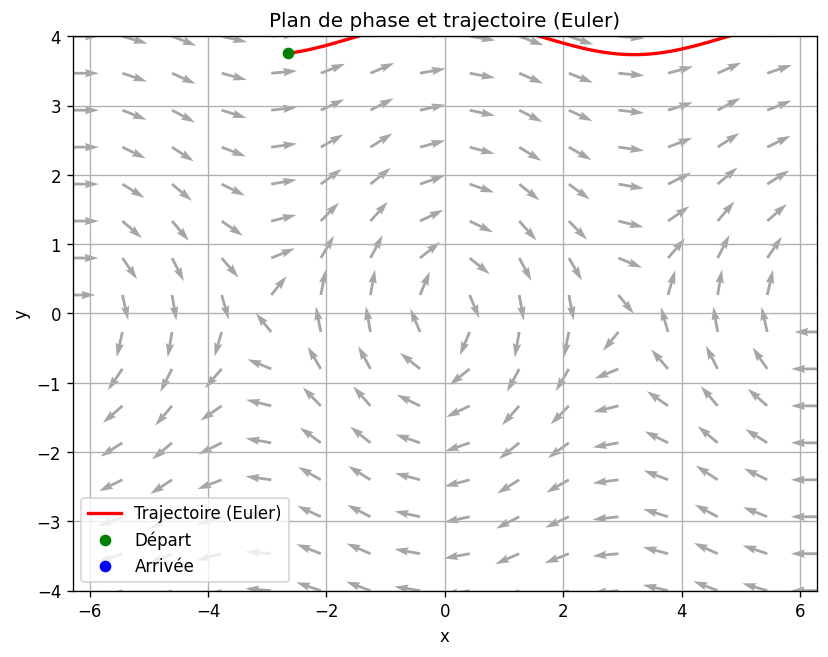

In [48]:
#Réponse:
def f(x, y):
    return y

def g(x, y):
    return -np.sin(x)

xmin = -2*np.pi
xmax = 2*np.pi
ymin = -4
ymax = 4
x0 = np.random.uniform(xmin,xmax)
y0 = np.random.uniform(ymin,ymax)
Tf = 30 #?
n = 1000 #?

plandephase(f, g, xmin, xmax, ymin, ymax, n, Tf, x0, y0)

## 3)
Ecrire une fonction $\tt{plandephase2}$ prenant en entrée les fonctions $f,g$, quatres valeurs $xmin < xmax, ymin < ymax$, un nombre $n$, un temps final $T_f$ et qui affiche sur une même figure
- le champs de vecteur $(x,y)\mapsto (f(x,y),g(x,y))$. On pourra utiliser la fonction donnée au début du TP avec un pas $p=15$.
- $n^2$ courbes correspondant  aux solutions approchées de (Eq) calculée par  un schéma d'Euler explicite sur l'intervalle $[0,T_f]$, avec la condition initiale $(x_0^i,y_0^j)$, $1\leq i \leq n$, $1\leq j \leq n$, où
$ x_0^i = xmin+(i-1) \frac{(xmax-xmin)}{(n-1)}, \qquad y_0^j = ymin+(j-1)\frac{(ymax-ymin)}{(n-1)} $.

La fenètre d'affichage sera restreinte à $[xmin,xmax]\times [ymin,ymax]$ (même si certaines courbes en sortent).

In [72]:
#Réponse:
def plandephase2(f, g, xmin, xmax, ymin, ymax, n, Tf):
    p=15
    x_vals = np.linspace(xmin, xmax, p+1)
    y_vals = np.linspace(ymin, ymax, p+1)
    X, Y = np.meshgrid(x_vals, y_vals)

    U = f(X, Y)
    V = g(X, Y)
    U=U*(ymax-ymin)/(xmax-xmin)#Changement d'echelle.
    U,V=U/np.sqrt(0.01+U**2+V**2),V/np.sqrt(0.01+U**2+V**2)#Normalisation du champs de vecteur: cela permet de rendre plus visible la direction.
    #plt.quiver(X,Y,U,V)#affiche le champs de vecteur: cette fonction trace le vecteur (u[i,j],v[i,j]) base en (x[i,j],y[i,j]), pour i,j qui parcourent [0,N]x[0,N]

    dt = Tf / n

    # points de depart
    x0_list = np.linspace(xmin, xmax, n)
    y0_list = np.linspace(ymin, ymax, n)

    for i in range(1, n+1):
       x0_list[i-1] = xmin +(i-1) * (xmax - xmin)/ (n-1)
    for j in range(1, n+1):
       y0_list[i-1] = ymin +(j-1) * (ymax - ymin)/ (n-1)

    plt.figure(figsize=(8, 6))
    plt.quiver(X, Y, U, V, color='gray', alpha=0.7)

    for x0 in x0_list:
        for y0 in y0_list:
            X_e = np.zeros(n+1)
            Y_e = np.zeros(n+1)
            X_e[0] = x0
            Y_e[0] = y0

            for i in range(n):
                X_e[i+1] = X_e[i] + dt * f(X_e[i], Y_e[i])
                Y_e[i+1] = Y_e[i] + dt * g(X_e[i], Y_e[i])

            plt.plot(X_e, Y_e, lw=0.8, alpha=0.7)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Plan de phase - plusieurs trajectoires (Euler)")
    plt.grid(True)
    plt.show()


## 4)
Appliquer cela au pendule $\ddot{x}(t)+\sin(x(t))=0$, sur l'intervalle $x\in [-2\pi,2\pi]$, $\dot{x}\in [-4,4]$. On prendra un temps final suffisament grand, et $n=4$.

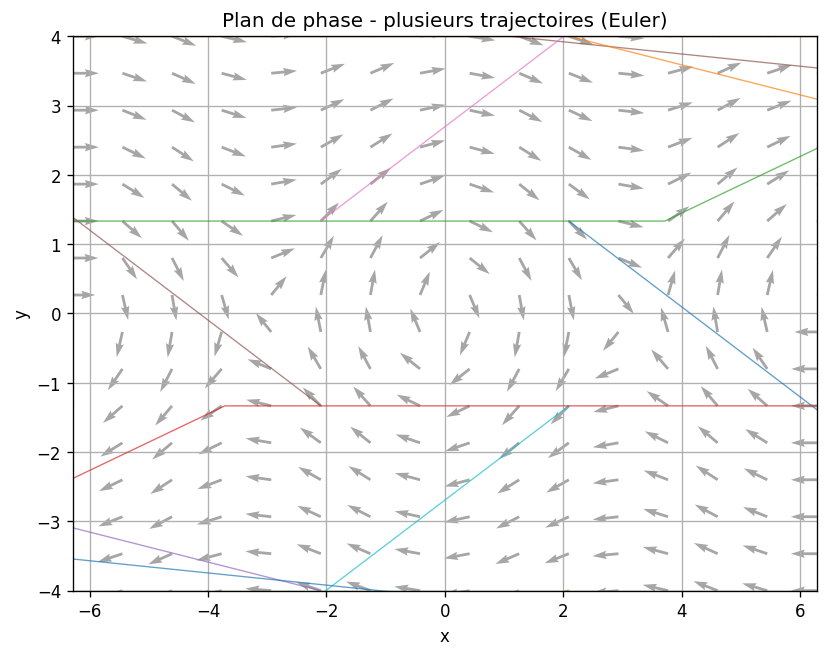

In [73]:
#Réponse:
def f(x, y):
    return y

def g(x, y):
    return -np.sin(x)

xmin = -2*np.pi
xmax = 2*np.pi
ymin = -4
ymax = 4
x0 = np.random.uniform(xmin,xmax)
y0 = np.random.uniform(ymin,ymax)
Tf = 30 #?
n = 4

plandephase2(f, g, xmin, xmax, ymin, ymax, n, Tf)

## 5)
Faire de même pour le pendule vibrant $\ddot{x}+\left(1+\frac{v^2}{2}\cos(x)\right)\sin(x)=0$ étudié au TP précédent, avec un paramètre $v$ faisant apparaître le phénomène de stabilité de la position verticale - on pourra prendre $v=2.5$.

In [10]:
#Réponse:

# Exercice 3 - Modèle de Lotka-Volterra avec croissance limitée

On considère ici le modèle proie-prédateur de Lotka-Volterra, en ajoutant dans le modèle un terme supplémentaire qui limite la croissance de proies.

$$\begin{cases}
\dot{x}(t)=x(t)(1- y(t)-\mu x(t))\\
\dot{y}(t)=y(t)(x(t)-1)
\end{cases}$$

$\mu$ est un paramètre strictement positif.

## 1)
Quelle fonction représente le nombre de proies, et laquelle le nombre de prédateurs ? Pourquoi ?


Réponse: 

## 2)
Donner une interprétation du  terme $-\mu x(t)^2$.

Réponse: 

## 2)
En utilisant l'exercice précédent, afficher le champs de vecteur et plusieurs solutions (une dizaines) dans une fenêtre $[0,3]^2$. On fera cela pour plusieurs valeurs du paramètre $\mu\in [0.2,0.5,0.8,1,1.5,2,4]$, chacun dans une fenètre séparée. Quel changement observe-t-on sur le champs de vecteurs ?



In [11]:
#Réponse:

## 3)
Calculer les points d'équilibres du système correspondant à des population positives (c'est-à-dire parmis les points $(x,y)\in \mathbb{R}^2$ tels que $x\geq 0$ et $y\geq 0$).

Réponse: